In [1]:
import requests
import pandas as pd
import numpy as np
import openai
import os
import json
from tqdm import tqdm
from pydantic import BaseModel
from dotenv import load_dotenv
load_dotenv()

client = openai.OpenAI(
	api_key=os.getenv("OPENAI_API_KEY"),
)

# Get data - OpenAlex

In [2]:
def query_openalex(search_string=None, filter_string=None, stop_after_n_results=50):
	# TODO: better error-handling; currently if an error occurs, all queries are lost
	# (replication OR replicate) NOT (virus OR dna)
	# (replication OR replicate)
	mylist = []

	base_url = f'https://api.openalex.org/works'
	if search_string:
		# sort only if there is a search string
		base_url += f"&search={search_string}&sort=relevance_score:desc"
	if filter_string:
		base_url += f"&filter={filter_string}"

	# adjust the silly query string thing but must be a better way with a python lib
	if search_string or filter_string:
		base_url = base_url.replace("/works&", "/works?")
		base_url += "&"
	else:
		base_url += "?"

	cursor = '*'
	print_once_flag = False #very silly but there we go
	progress_bar = tqdm(total=stop_after_n_results, desc="Fetching OpenAlex Results", unit="result")
	while cursor:
		url = f"{base_url}cursor={cursor}"
		request = requests.get(url)
		if request.status_code != 200:
			raise Exception(f"Error GET request: {request.status_code}; {request.text}")
		page_with_results = request.json()
		
		results = page_with_results['results']
		if not print_once_flag:
			print(f"Total results from query: {page_with_results['meta']['count']}")
			print_once_flag = True
		for i, work in enumerate(results):
			# temp filter
			if 'virus' in work['display_name'].lower() or 'dna' in work['display_name'].lower():
				continue

			curr_work_obj = {
				'title': work['display_name'],
				'abstract': ' '.join(work['abstract_inverted_index'].keys()) if work['abstract_inverted_index'] else None,
				'year': work['publication_year'],
				'authors': ", ".join([e['author']['display_name'] for e in work['authorships']]),
				'doi': work['ids'].get('doi') or work['ids'].get('openalex')
			}
			mylist.append(curr_work_obj)

			progress_bar.update(1)

		# outisde the for loop just so that on the last request we can add all the requests
		# instead of dropping some after the stop_after_n_results
		# i.e. stop_after_n_results is a soft-stop
		if len(mylist)>stop_after_n_results:
			cursor = None
			progress_bar.close()
		else:
			cursor = page_with_results['meta'].get('next_cursor')
	
	progress_bar.close()

	df = pd.DataFrame(mylist)
	return df

# Get data - Crossref

Delivers only 82k results on search for "replication" ?!

In [8]:
base_url="https://api.crossref.org/works"
url = base_url + "?query.bibliographic=replication"

response = requests.get(url)
# response.status_code
response.json()['message']['total-results']

81947

# Get data - Google Scholar

* serapi

	* decent general results, but no abstracts

* `scholarly`

	* Slow
	* uses scraping (against TOS)
	* diffuclt to setup/maintain (proxies)
	* still no abstracts (says abstracts but delivers 'snippet' text or w/e it is)

In [9]:
from serpapi import GoogleSearch

params = {
  "engine": "google_scholar",
  "q": "replication",
  "api_key": os.getenv("GOOGLE_SCHOLAR_API_KEY")
}

search = GoogleSearch(params)
results = search.get_dict()
# organic_results = results["organic_results"]
results['search_information']['total_results']

5540000

In [5]:
# from scholarly import scholarly

# search_query = scholarly.search_pubs("replication")

# results = []
# for _ in range(10):
#     try:
#         publication = next(search_query)
#         filled_publication = scholarly.fill(publication)
#         results.append(filled_publication)
#     except StopIteration:
#         break

# Get data - CORE

Includes only Open Access paper - 1M for 'replication' search

In [10]:
url = "https://api.core.ac.uk/v3/search/works?q=replication&stats=True"
headers={
    'Authorization': f"Bearer: {os.getenv('CORE_API_KEY')}"
}
response = requests.get(url, headers=headers)
# response.status_code
response.json()['totalHits']

939589

# Other sources of data

* Semantic Scholar API [not maintaned](https://github.com/allenai/s2-folks)
* DataCite API - Does not seem suitable
* [Arxiv API](https://info.arxiv.org/help/api/index.html) - Maybe?

Other options:
* [Lens](https://www.lens.org/)
* [List of others](https://guides.lib.berkeley.edu/information-studies/apis)

# Dedup & filtering search results

In [11]:
def filter_results(current_results_df, existing_results_df=None):
	# TODO: don't use dfs as they are quite slow
	# TODO: overwrite objects to preserve memory
	# TODO: add more filtering than just doi
	if existing_results_df is None:
		return current_results_df

	filtered_results_df = current_results_df[~current_results_df['doi'].isin(existing_results_df['doi'])]
	print(f"Results filtered from {len(current_results_df)} to {len(filtered_results_df)}")
	return filtered_results_df

# Get LLM evaluation

In [12]:
class ResearchPaperExtraction(BaseModel):
	replication: bool
	reason: str
	
def openai_object_to_dict(obj, visited=None):
	"""
	Recursively converts an OpenAI response/model object into a JSON-serializable dictionary
	by calling __dict__ on each nested object, if available.

	:param obj: The initial object (e.g., a ChatCompletion response from OpenAI).
	:param visited: A set to track visited objects and avoid infinite recursion for circular references.
	:return: A dictionary (or basic Python object) that can be serialized to JSON.
	"""
	if visited is None:
		visited = set()

	# Avoid infinite recursion in case of circular references
	obj_id = id(obj)
	if obj_id in visited:
		return None
	visited.add(obj_id)

	# Base types can be returned as-is
	if isinstance(obj, (str, int, float, bool, type(None))):
		return obj
	
	# If it's a list or tuple, process each item
	if isinstance(obj, (list, tuple)):
		return [openai_object_to_dict(item, visited) for item in obj]
	
	# If it's a dictionary, process each key/value
	if isinstance(obj, dict):
		return {k: openai_object_to_dict(v, visited) for k, v in obj.items()}

	# If the object has __dict__, convert it recursively
	if hasattr(obj, '__dict__'):
		# Here we convert all attributes, skipping those starting with '__' by convention
		return {
			k: openai_object_to_dict(v, visited)
			for k, v in obj.__dict__.items()
			if not k.startswith('__')
		}

	# Fallback: convert to string if we have no better way
	return str(obj)
	
def append_to_jsonl(data, filename="requests_log.jsonl"):
	"""Append a json payload to the end of a jsonl file."""
	json_string = json.dumps(data)
	with open(filename, "a") as f:
		f.write(json_string + "\n")
		
def get_response(title, abstract, model='gpt-4o', metadata={}):
	# ORIGINAL PROMPT USED FOR EVALS BELOW
	prompt = f"""
	Your task is to analyse the title and the abstract of an academic article and decide if it classifies as a replication using the following criteria:
	- A replication is defined as testing an existing hypothesis or theory with new data or methods
	- Rerunning existing code does NOT classify as a replication
	- The article must report quantitative research to test specific hypotheses or answer specific questions
	- The article must not report a meta-analysis or review
	- The article must not report a theoretical or conceptual paper
	- The article must not concern DNA replication, virus replication, genome replication or similar where replication refers to something different than the above-stated definition
	- The article may or may not explicitly mention that it is a replication in the title or abstract but as long as it tests an existing hypothesis on new data, it would classify as one.
	
	Return your answer as a JSON with two fields:
	- replication: Boolean (true/false)
	- reason: String (a brief explanation of why the article is/is not a replication)

	Title of the article: {title}
	Here's abstract to consider:
	{abstract}
	"""

	# NEW PROMPT
	# do not ask for a reason; can include abstract or not
	# Very talkative (~350 tokens) if you ask for a reason in the structured field, but do not explicitly tell it to be brief (<100 tokens).
	# prompt = f"""
	# Your task is to analyse information from an academic article and decide if it classifies as a replication using the following criteria:
	# - A replication is defined as testing an existing hypothesis or theory with new data or methods
	# - Rerunning existing code does NOT classify as a replication
	# - The article must report quantitative research to test specific hypotheses or answer specific questions
	# - The article must not report a meta-analysis or review
	# - The article must not report a theoretical or conceptual paper
	# - The article must not concern DNA replication, virus replication, genome replication or similar where replication refers to something different than the above-stated definition
	# - The article may or may not explicitly mention that it is a replication in the title or abstract but as long as it tests an existing hypothesis on new data, it would classify as one.
	# - The article should not be an analysis of other replications, but must be a replication itself
	# - The article may report multiple replications

	# Title of the article: {title}
	# Abstract of the article:
	# {abstract}
	# """
	  
	# TODO: vectorize the function and add batch mode so that if the user
	# passes a list of requests, we can apply batch openai mode
	# NOTE: max_tokens not needed: if reasoning needed, ask the model to be brief and it does OKAY; if no reasoning then the structured output is sufficient
	request_json = {
		"model": model,
		"temperature": 0,
		"messages": [
			# {"role": "system", "content": "You perform a scientific task of very high importance."},
			{"role": "user", "content": prompt},
		]
	}
	  
	response = client.beta.chat.completions.parse(
		model=request_json['model'],
		temperature=request_json['temperature'],
		messages=request_json['messages'],
		response_format=ResearchPaperExtraction,
	)

	# response is a chat completion object -- https://platform.openai.com/docs/api-reference/chat/object
	append_to_jsonl({"request": request_json, "response": openai_object_to_dict(response), "metadata": metadata})
	  
	try:
		response_json = json.loads(response.choices[0].message.content)
	except json.JSONDecodeError:
		response_json = {"replication": None, "reason": "The LLM response was not in a valid JSON format."}
	
	return (response._request_id, response_json)

def get_llm_evaluations(df, model):
	# TODO change this to kwargs and pass those to get_response
	# TODO set up batch mode
	df[f"replication_{model}"] = None
	df[f"reason_{model}"] = None
	df[f"request_id_{model}"] = None

	for ind, row in tqdm(df.iterrows(), total=len(df)-1, desc=model):
		request_id, response_json = get_response(row['title'], row['abstract'], model, metadata={})

		df.at[ind, f"replication_{model}"] = response_json.get("replication")
		df.at[ind, f"reason_{model}"]      = response_json.get("reason")
		df.at[ind, f"request_id_{model}"]  = request_id
		
	return df

# Demo queries

## Get data

In [13]:
# 10_000 results takes about 12 minutes

# df = query_openalex("(replication OR replicate) NOT (virus OR dna)", "has_abstract:true", stop_after_n_results=10000)
# df.to_csv("openalex_results_10000.csv", index=False)

df = pd.read_csv("openalex_results_10000.csv")
print(df.shape)
df.head()

(10003, 5)


,title,abstract,year,authors,doi
0,"Knowledge of the Firm, Combinative Capabilitie...",How should we understand why firms exist? A pr...,1992,"Bruce Kogut, Udo Zander",https://doi.org/10.1287/orsc.3.3.383
1,"Prevalence, Severity, and Comorbidity of 12-Mo...",<h3>Background</h3> Little is known about the ...,2005,"Ronald C. Kessler, Wai Tat Chiu, Olga Demler, ...",https://doi.org/10.1001/archpsyc.62.6.617
2,Lifetime Prevalence and Age-of-Onset Distribut...,Little is known about lifetime prevalence or a...,2005,"Ronald C. Kessler, Patricia A. Berglund, Olga ...",https://doi.org/10.1001/archpsyc.62.6.593
3,Better reporting of interventions: template fo...,Without a complete published description of in...,2014,"Tammy Hoffmann, Paul Glasziou, Isabelle Boutro...",https://doi.org/10.1136/bmj.g1687
4,Extension of Multiple Range Tests to Group Mea...,"In many fields of research, one is faced with ...",1956,Clyde Young Kramer,https://doi.org/10.2307/3001469


## LLM evaluations

In [14]:
# df_sample_1 = df[df.index.isin([38, 42, 43, 44, 45])].reset_index(drop=True)
# df_sample_1 = get_llm_evaluations(df_sample_1, "gpt-4o")
# df_sample_1 = get_llm_evaluations(df_sample_1, "gpt-4o-mini")
# df_sample_1.to_csv("df_sample_1.csv", index=False)
df_sample_1 = pd.read_csv("df_sample_1.csv")
df_sample_1.head()

,title,abstract,year,authors,doi,replication_gpt-4o,reason_gpt-4o,request_id_gpt-4o,replication_gpt-4o-mini,reason_gpt-4o-mini,request_id_gpt-4o-mini
0,Mindfulness-Based Cognitive Therapy for Depres...,Recovered recurrently depressed patients were ...,2004,"S. Helen, John D. Teasdale",https://doi.org/10.1037/0022-006x.72.1.31,True,The study tests an existing hypothesis regardi...,req_518b003213fc7064c9cb8dba22d7e787,True,The article tests the effectiveness of Mindful...,req_b7f40d49baa4c723e89cb9c71c60400c
1,Option Pricing and Replication with Transactio...,ABSTRACT Transactions costs invalidate the Bla...,1985,Hayne E. Leland,https://doi.org/10.1111/j.1540-6261.1985.tb023...,False,The article focuses on developing a modified r...,req_e6258d440f5cb1677d8d98283a8abc3d,True,The article tests an existing hypothesis relat...,req_95f8e1728c34db8efb742bb18364278c
2,"Rank products: a simple, yet powerful, new met...",One of the main objectives in analysis microar...,2004,"Rainer Breitling, Patrick Armengaud, Anna Amtm...",https://doi.org/10.1016/j.febslet.2004.07.055,False,The article introduces a new method for analyz...,req_c85ff5ee0682ea29c5233d6c659cdf37,True,The article presents a new method for detectin...,req_e28b17b6ec47b11e710640fb460e0ea9
3,Replicated microarray data,cDNA microarrays permit us to study the expres...,2001,Ingrid Lönnstedt,https://openalex.org/W2105793531,False,The article presents a new empirical Bayes met...,req_343df53693fb19113e9d5a0dc7ee9632,True,The article presents a new method for analyzin...,req_61967d358a9acdb9cb42f4047963d3b3
4,Relationship between hopelessness and ultimate...,"A prospective study of 1,958 outpatients found...",1990,"A T Beck, Gary Brown, Robert J. Berchick, Bonn...",https://doi.org/10.1176/ajp.147.2.190,True,The article tests an existing hypothesis about...,req_6b1201bd70a40522f93fbafa00a49460,True,The article tests the existing hypothesis that...,req_86b71b951bacd9886187df492b871d35


In [15]:
# df_sample_2 = df[df.index.isin([48, 49, 50, 51, 52, 53, 54, 55])].reset_index(drop=True)
# df_sample_2 = get_llm_evaluations(df_sample_2, "gpt-4o")
# df_sample_2 = get_llm_evaluations(df_sample_2, "gpt-4o-mini")
# # df_sample_2.to_csv("df_sample_2.csv", index=False)
df_sample_2 = pd.read_csv("df_sample_2.csv")
df_sample_2.head()

,title,abstract,year,authors,doi,replication_gpt-4o,reason_gpt-4o,request_id_gpt-4o,replication_gpt-4o-mini,reason_gpt-4o-mini,request_id_gpt-4o-mini
0,The Value of Direct Replication,Reproducibility is the cornerstone of science....,2014,Daniel J. Simons,https://doi.org/10.1177/1745691613514755,False,The article appears to be a commentary discuss...,req_c6c89b922d1991b2432b7dc9a0ace02d,False,The article discusses the concept of direct re...,req_7ce0ed44962dd50ad8b9e1394bad9897
1,A Multilab Preregistered Replication of the Eg...,Good self-control has been linked to adaptive ...,2016,"Martin S. Hagger, Nikos L. D. Chatzisarantis, ...",https://doi.org/10.1177/1745691616652873,True,The article describes a multilab preregistered...,req_fca6932f04b9522977e85925ea3f4b14,True,The article tests the existing hypothesis of t...,req_e7fe2a762ce18a88e47e3721440e6381
2,Reproducibility and Replicability in Science,One of the pathways by which scientific commun...,2019,NaN,https://doi.org/10.17226/25303,False,The article discusses the concepts of reproduc...,req_80281bb1ce4333719f2741229829ad0d,False,The article discusses reproducibility and repl...,req_23b07cc04241e2500f7730f114127a1f
3,Self-Sustained Replication of an RNA Enzyme,An RNA enzyme that catalyzes the RNA-templated...,2009,"Tracey A. Lincoln, Gerald F. Joyce",https://doi.org/10.1126/science.1167856,False,The article focuses on the self-sustained repl...,req_d23b3240d267bdc690b8afc24493e8db,False,The article concerns RNA enzyme replication in...,req_6046b7048bebab5936c422bb22bc4e0a
4,Distributed Detection of Node Replication Atta...,"The low-cost, off-the-shelf hardware component...",2005,"Bryan Parno, Adrian Perrig, Virgil D. Gligor",https://doi.org/10.1109/sp.2005.8,False,The article proposes new algorithms for detect...,req_2ec37d47a75b3ace3603a038f27c74af,False,The article discusses new algorithms for detec...,req_19eb029751f942842eaf07b1e900025c


In [16]:
# first time I ran this I did not include a random state, so we'll read from csv as results won't be reproducible
# df_sample_3 = df.sample(20, random_state=42).reset_index(drop=True)
# df_sample_3 = filter_results(df_sample_3, pd.concat([df_sample_1, df_sample_2])[['doi']].reset_index(drop=True))
# df_sample_3 = get_llm_evaluations(df_sample_3, "gpt-4o")
# df_sample_3 = get_llm_evaluations(df_sample_3, "gpt-4o-mini")
# df_sample_3.to_csv("df_sample_3.csv", index=False)
df_sample_3 = pd.read_csv("df_sample_3.csv")
df_sample_3.head()

,title,abstract,year,authors,doi,replication_gpt-4o,reason_gpt-4o,request_id_gpt-4o,replication_gpt-4o-mini,reason_gpt-4o-mini,request_id_gpt-4o-mini
0,Inhibitors of Strand Transfer That Prevent Int...,Integrase is essential for human immunodeficie...,2000,"Daria J. Hazuda, Peter J. Felock, Marc Witmer,...",https://doi.org/10.1126/science.287.5453.646,False,The article focuses on the biochemical inhibit...,req_1533d9677596bd1c7b032a3b55aa1175,False,The article focuses on inhibitors of HIV-1 rep...,req_1a190b81b1fd382fcabf78b6523ce000
1,Lounging in a lysosome: the intracellular life...,Most intracellular parasites employ sophistica...,2007,"Daniel E. Voth, Robert A. Heinzen",https://doi.org/10.1111/j.1462-5822.2007.00901.x,False,The article is a summary of current understand...,req_50a5488a448133073708c6fe472c9bd3,False,The article does not test an existing hypothes...,req_c0a50273a2b9f4e0ed410e2d54c45460
2,Estimating the reproducibility of psychologica...,Reproducibility is a defining feature of scien...,2015,"Alexander A. Aarts, Joanna E. Anderson, Christ...",https://doi.org/10.1126/science.aac4716,True,The article describes conducting replications ...,req_7163ed3e94f81727f21c161f3444b7c1,True,The article tests existing hypotheses in psych...,req_fddbbd9f0facfc1db635dc57715c6b22
3,Single-Item Reliability: A Replication and Ext...,The reliability of a single-item measure stude...,2001,"John P. Wanous, Michael J. Hudy",https://doi.org/10.1177/109442810144003,True,The article tests the existing hypothesis rega...,req_148ce11ed2f97262cae6b67c7ece0414,True,The article tests an existing hypothesis regar...,req_e2faf2e6b653ffc69a70ffee4740af0e
4,The replicator equation and other game dynamics,The replicator equation is the first and most ...,2014,"Ross Cressman, Yi Tao",https://doi.org/10.1073/pnas.1400823111,False,The article discusses the replicator equation ...,req_0c0098d02a3e2d2c23b7bd769aa549eb,False,The article discusses the replicator equation ...,req_09f2e5e239ff073673328d1598127ce7


In [17]:
# df_sample_4 = df.sample(40, random_state=43).reset_index(drop=True)
# df_sample_4 = filter_results(df_sample_4, pd.concat([df_sample_1, df_sample_2, df_sample_3])[['doi']].reset_index(drop=True))
# df_sample_4 = get_llm_evaluations(df_sample_4, "gpt-4o")
# df_sample_4 = get_llm_evaluations(df_sample_4, "gpt-4o-mini")
# df_sample_4.to_csv("df_sample_4.csv", index=False)
df_sample_4 = pd.read_csv("df_sample_4.csv")
df_sample_4.head()

,title,abstract,year,authors,doi,replication_gpt-4o,reason_gpt-4o,request_id_gpt-4o,replication_gpt-4o-mini,reason_gpt-4o-mini,request_id_gpt-4o-mini
0,Structure and Base Pairing Properties of a Rep...,"We report the synthesis, structure, and pairin...",1998,"Kevin M. Guckian, Juan Carlos Morales, Eric T....",https://doi.org/10.1021/jo9805100,False,The article focuses on the synthesis and struc...,req_65bab9216a292db8646e15eec49478b3,False,The article focuses on the synthesis and prope...,req_db34f8e83ac7987f6d3cb301d55e7be7
1,Inhibition of HIV-1 Replication by a Nonnucleo...,A series of dipyridodiazepinones have been sho...,1990,"Vincent J. Merluzzi, Karl D. Hargrave, Mark E....",https://doi.org/10.1126/science.1701568,False,The article focuses on the inhibition of HIV-1...,req_8ac539c832a32e2f32e3ff1518bdb78c,False,The article focuses on the inhibition of HIV-1...,req_4165bee89fc3358aaad24e408c8744b8
2,Quantitative Comparison of HTLV-1 and HIV-1 Ce...,We have developed an efficient method to quant...,2010,"Dmitriy Mazurov, Anna Ilinskaya, Gisela Heidec...",https://doi.org/10.1371/journal.ppat.1000788,False,The article describes the development of a new...,req_7cea1e50c0ddfa4a968649463434610b,True,The article tests existing hypotheses regardin...,req_eb1cbab535a43c707792642fa3b0fe5d
3,Electron microscope study of a plasmid chimera...,"pML31, a plasmid chimera constructed to contai...",1976,"Mark S. Guyer, David H. Figurski, N Davidson",https://doi.org/10.1128/jb.127.2.988-997.1976,False,The article focuses on the study of a plasmid ...,req_3c4a0163e70698b4515c2ff558aa6af8,False,The article focuses on a study of a plasmid ch...,req_f6676f65d2d8fe58f1fce6692e11658a
4,Efficient and Deterministic Scheduling for Par...,Many services used in large scale web applicat...,2017,"Odorico Machado Mendizabal, Ruda S. T. De Mour...",https://doi.org/10.1109/ipdps.2017.29,False,The article proposes a new scheduling techniqu...,req_52469c563b76b9e5fc48348cbfb4e77c,False,The article focuses on proposing a new schedul...,req_bc3d9711e73b748f2f9c768a8203facd


In [18]:
# fred_database = pd.read_csv("FReD-2025-01-28.csv")
# fred_database = fred_database[~pd.isna(fred_database["doi_replication"])][["doi_replication"]].drop_duplicates().reset_index(drop=True)
# fred_database["doi_replication"] = fred_database["doi_replication"].apply(lambda x: f"https://doi.org/{x}")
# print(fred_database.shape)

# filter_string = f"has_abstract:true,doi:{'|'.join(fred_database['doi_replication'].sample(80, random_state=42).tolist())}"

# df_sample_5 = query_openalex(filter_string=filter_string)
# df_sample_5 = filter_results(df_sample_5, pd.concat([df_sample_1, df_sample_2, df_sample_3, df_sample_4])[['doi']].reset_index(drop=True))
# df_sample_5 = get_llm_evaluations(df_sample_5, "gpt-4o")
# df_sample_5 = get_llm_evaluations(df_sample_5, "gpt-4o-mini")
# df_sample_5.to_csv("df_sample_5.csv", index=False)
df_sample_5 = pd.read_csv("df_sample_5.csv")
df_sample_5.head()

,title,abstract,year,authors,doi,replication_gpt-4o,reason_gpt-4o,request_id_gpt-4o,replication_gpt-4o-mini,reason_gpt-4o-mini,request_id_gpt-4o-mini
0,Is Implicit Theory of Mind a Real and Robust P...,"Recently, theory-of-mind research has been rev...",2018,"Louisa Kulke, Britta von Duhn, Dana Schneider,...",https://doi.org/10.1177/0956797617747090,True,The article reports a systematic replication s...,req_835325ad78b03848988e10198fb99d29,True,The article tests an existing hypothesis about...,req_bb8db94d97ca02e5aa8072ed6651f493
1,Does spending money on others promote happines...,Research indicates that spending money on othe...,2020,"Lara B. Aknin, Elizabeth W. Dunn, Jason D. E. ...",https://doi.org/10.1037/pspa0000191,True,The article tests an existing hypothesis that ...,req_650cf74d090d83673b553fb4d4b46e9f,True,The article tests the existing hypothesis that...,req_d41a2381c1e877ff5aed3b63a9c13a69
2,Does Cleanliness Influence Moral Judgments?,"Schnall, Benton, and Harvey (2008) hypothesize...",2014,"David J. Johnson, Felix Cheung, M. Brent Donne...",https://doi.org/10.1027/1864-9335/a000186,True,The article tests an existing hypothesis by Sc...,req_c3798b1fa5aa6d3a4d0ec2a051ab65ea,True,The article tests the existing hypothesis that...,req_8ba2f416e4735da9f23ce1452c4d56de
3,Lessons to be popular: the chemical basis of a...,Aggregation is one of the most remarkable beha...,2024,"David Alavez‐Rosas, Ana E. Gutiérrez‐Cabrera, ...",https://doi.org/10.1098/rsos.231271,False,The article does not test an existing hypothes...,req_771a05883493861c9048213c5c0f4ccb,False,The article does not test an existing hypothes...,req_73342d6563b723c661fadfd760ad3da9
4,Pneumatic elastostatics of multi-functional in...,As a consequence of intense investigation on p...,2024,"P K Sinha, T. Mukhopadhyay",https://doi.org/10.1098/rsos.231272,False,The article introduces a novel class of inflat...,req_0fa56e0ecb55c0ee9dee03db4695a5ad,False,The article does not test an existing hypothes...,req_a79448b8bfb5c7490a11f3197d35dcc9


## Comparison to ground truth

In [ ]:
# temp helper for formatting
# for e in df_sample_5['doi'].to_list():
# 	print(e)

In [19]:
df_ground_truth = pd.DataFrame([
	# sample 1
	{'doi': 'https://doi.org/10.1037/0022-006x.72.1.31', 'replication_ground_truth': True},
	{'doi': 'https://doi.org/10.1111/j.1540-6261.1985.tb02383.x', 'replication_ground_truth': False},
	{'doi': 'https://doi.org/10.1016/j.febslet.2004.07.055', 'replication_ground_truth': False},
	{'doi': 'https://openalex.org/W2105793531', 'replication_ground_truth': False},
	{'doi': 'https://doi.org/10.1176/ajp.147.2.190', 'replication_ground_truth': True},
	# sample 2
	{'doi': 'https://doi.org/10.1177/1745691613514755', 'replication_ground_truth': False},
	{'doi': 'https://doi.org/10.1177/1745691616652873', 'replication_ground_truth': True},
	{'doi': 'https://doi.org/10.17226/25303', 'replication_ground_truth': False},
	{'doi': 'https://doi.org/10.1126/science.1167856', 'replication_ground_truth': False},
	{'doi': 'https://doi.org/10.1109/sp.2005.8', 'replication_ground_truth': False},
	{'doi': 'https://doi.org/10.1093/bioinformatics/btm233', 'replication_ground_truth': False},
	{'doi': 'https://doi.org/10.1109/sfcs.1997.646125', 'replication_ground_truth': False},
	{'doi': 'https://doi.org/10.1126/science.278.5341.1291', 'replication_ground_truth': False},
	# sample 3
	{'doi': 'https://doi.org/10.1126/science.287.5453.646', 'replication_ground_truth': False},
	{'doi': 'https://doi.org/10.1111/j.1462-5822.2007.00901.x', 'replication_ground_truth': False},
	{'doi': 'https://doi.org/10.1126/science.aac4716', 'replication_ground_truth': True},
	{'doi': 'https://doi.org/10.1177/109442810144003', 'replication_ground_truth': True}, # not 100% clear based on title/abstract, but I'd classify as True as it needs further investigation 
	{'doi': 'https://doi.org/10.1073/pnas.1400823111', 'replication_ground_truth': False}, 
	{'doi': 'https://doi.org/10.1037/0021-9010.90.6.1228', 'replication_ground_truth': True}, # not 100% clear, but again I'd classify as replication as it needs full-text examination
	{'doi': 'https://doi.org/10.1177/1745691612459520', 'replication_ground_truth': False},
	{'doi': 'https://doi.org/10.1126/science.268.5216.1466', 'replication_ground_truth': False},
	{'doi': 'https://doi.org/10.1111/j.1442-9993.1993.tb00437.x', 'replication_ground_truth': False},
	{'doi': 'https://doi.org/10.1111/j.1365-2966.2007.00428.x', 'replication_ground_truth': False},
	{'doi': 'https://doi.org/10.1177/1745691612460686', 'replication_ground_truth': False},
	{'doi': 'https://doi.org/10.1109/2.585156', 'replication_ground_truth': False},
	{'doi': 'https://doi.org/10.1109/18.850663', 'replication_ground_truth': False},
	{'doi': 'https://doi.org/10.1146/annurev.bi.61.070192.004341', 'replication_ground_truth': False},
	{'doi': 'https://openalex.org/W1550564711', 'replication_ground_truth': False},
	{'doi': 'https://doi.org/10.1177/1745691616646366', 'replication_ground_truth': False},
	{'doi': 'https://doi.org/10.1177/0956797615616374', 'replication_ground_truth': False},
	{'doi': 'https://doi.org/10.1017/s1049096500057607', 'replication_ground_truth': False},
	{'doi': 'https://doi.org/10.1016/j.antiviral.2020.104787', 'replication_ground_truth': False},
	{'doi': 'https://doi.org/10.4049/jimmunol.157.3.1271', 'replication_ground_truth': False},
    # sample 4
    {'doi': 'https://doi.org/10.1021/jo9805100', 'replication_ground_truth': False},
	{'doi': 'https://doi.org/10.1126/science.1701568', 'replication_ground_truth': False},
	{'doi': 'https://doi.org/10.1371/journal.ppat.1000788', 'replication_ground_truth': False},
	{'doi': 'https://doi.org/10.1128/jb.127.2.988-997.1976', 'replication_ground_truth': False},
	{'doi': 'https://doi.org/10.1109/ipdps.2017.29', 'replication_ground_truth': False},
	{'doi': 'https://doi.org/10.1111/j.1559-1816.1975.tb00687.x', 'replication_ground_truth': True},
	{'doi': 'https://doi.org/10.1890/07-1127.1', 'replication_ground_truth': False}, # not super clear though as they could be replicating preivous work somewhere in the methods as a way to test the new method
	{'doi': 'https://doi.org/10.1001/archgenpsychiatry.2010.189', 'replication_ground_truth': False},
	{'doi': 'https://doi.org/10.1097/00007632-200110150-00012', 'replication_ground_truth': False},
	{'doi': 'https://doi.org/10.1364/oe.16.013534', 'replication_ground_truth': False},
	{'doi': 'https://doi.org/10.1128/iai.00449-06', 'replication_ground_truth': False},
	{'doi': 'https://doi.org/10.1093/nar/gkq343', 'replication_ground_truth': False},
	{'doi': 'https://doi.org/10.2307/3802926', 'replication_ground_truth': False},
	{'doi': 'https://doi.org/10.1109/tdsc.2010.70', 'replication_ground_truth': False},
	{'doi': 'https://openalex.org/W176521151', 'replication_ground_truth': False},
	{'doi': 'https://doi.org/10.3390/genes8020055', 'replication_ground_truth': False},
	{'doi': 'https://doi.org/10.1021/acsami.6b06209', 'replication_ground_truth': False},
	{'doi': 'https://openalex.org/W2314701107', 'replication_ground_truth': True},
	{'doi': 'https://doi.org/10.1146/annurev-biochem-013118-110644', 'replication_ground_truth': False},
	{'doi': 'https://doi.org/10.1002/hrm.20325', 'replication_ground_truth': False},
	{'doi': 'https://doi.org/10.1534/genetics.105.043026', 'replication_ground_truth': False},
	{'doi': 'https://doi.org/10.1128/iai.63.9.3253-3258.1995', 'replication_ground_truth': False},
	{'doi': 'https://doi.org/10.1101/87969139.11a.27', 'replication_ground_truth': False},
	{'doi': 'https://doi.org/10.1037/h0100104', 'replication_ground_truth': False},
	{'doi': 'https://doi.org/10.1038/srep28171', 'replication_ground_truth': False},
	{'doi': 'https://doi.org/10.1177/1094342013505348', 'replication_ground_truth': False},
	{'doi': 'https://doi.org/10.1093/humupd/dmu015', 'replication_ground_truth': False},
	{'doi': 'https://doi.org/10.1098/rspa.1980.0135', 'replication_ground_truth': False},
	{'doi': 'https://doi.org/10.1109/hicss.2009.225', 'replication_ground_truth': True}, # not 100% sure though
	{'doi': 'https://doi.org/10.1128/iai.00238-07', 'replication_ground_truth': False},
	{'doi': 'https://doi.org/10.1002/elps.200600239', 'replication_ground_truth': False},
	{'doi': 'https://doi.org/10.1109/rtcsa.2007.72', 'replication_ground_truth': False},
	{'doi': 'https://doi.org/10.2174/138161213805219711', 'replication_ground_truth': False},
	{'doi': 'https://doi.org/10.1074/jbc.m111.250092', 'replication_ground_truth': False},
	{'doi': 'https://doi.org/10.1002/(sici)1097-0266(199708)18:7<509::aid-smj882>3.0.co;2-z', 'replication_ground_truth': False},
	{'doi': 'https://doi.org/10.1109/icdcs.workshops.2008.92', 'replication_ground_truth': False},
	{'doi': 'https://doi.org/10.2337/db05-1034', 'replication_ground_truth': False},
	{'doi': 'https://doi.org/10.1016/j.celrep.2013.02.007', 'replication_ground_truth': False},
	{'doi': 'https://doi.org/10.1017/epi.2015.17', 'replication_ground_truth': True},
    # sample 5 - Even though these were searched based on FRED database, some entries are not from there for whatever reason
    # hence, these are re-evaluated
    {'doi': 'https://doi.org/10.1177/0956797617747090', 'replication_ground_truth': True},
	{'doi': 'https://doi.org/10.1037/pspa0000191', 'replication_ground_truth': True},
	{'doi': 'https://doi.org/10.1027/1864-9335/a000186', 'replication_ground_truth': True},
	{'doi': 'https://doi.org/10.1098/rsos.231271', 'replication_ground_truth': False},
	{'doi': 'https://doi.org/10.1098/rsos.231272', 'replication_ground_truth': False},
	{'doi': 'https://doi.org/10.1098/rsos.231331', 'replication_ground_truth': False},
	{'doi': 'https://doi.org/10.1098/rsos.231265', 'replication_ground_truth': False},
	{'doi': 'https://doi.org/10.1098/rsos.231353', 'replication_ground_truth': False},
	{'doi': 'https://doi.org/10.1098/rsos.231369', 'replication_ground_truth': False},
	{'doi': 'https://doi.org/10.1016/j.actpsy.2022.103497', 'replication_ground_truth': True},
	{'doi': 'https://doi.org/10.1098/rsos.231397', 'replication_ground_truth': False},
	{'doi': 'https://doi.org/10.1098/rsos.231314', 'replication_ground_truth': False},
	{'doi': 'https://doi.org/10.1098/rsos.231348', 'replication_ground_truth': False},
	{'doi': 'https://doi.org/10.1098/rsos.231326', 'replication_ground_truth': True},
	{'doi': 'https://doi.org/10.1177/2515245919881152', 'replication_ground_truth': True},
	{'doi': 'https://doi.org/10.1098/rsos.231259', 'replication_ground_truth': False},
	{'doi': 'https://doi.org/10.1098/rsos.231240', 'replication_ground_truth': True}, # I would keep it as true as it is not clear if this is just analysis of replications or presents a dataset with new replications
	{'doi': 'https://doi.org/10.1098/rsos.231386', 'replication_ground_truth': False},
	{'doi': 'https://doi.org/10.1098/rsos.231304', 'replication_ground_truth': False},
	{'doi': 'https://doi.org/10.1177/0956797620953842', 'replication_ground_truth': True},
	{'doi': 'https://doi.org/10.1177/0956797620922477', 'replication_ground_truth': True},
	{'doi': 'https://doi.org/10.1098/rsos.210641', 'replication_ground_truth': True},
	{'doi': 'https://doi.org/10.1080/15248372.2018.1544140', 'replication_ground_truth': True},
	{'doi': 'https://doi.org/10.1098/rsos.231261', 'replication_ground_truth': False},
	{'doi': 'https://doi.org/10.1098/rsos.231362', 'replication_ground_truth': False},
	{'doi': 'https://doi.org/10.1027/1618-3169/a000567', 'replication_ground_truth': True},
	{'doi': 'https://doi.org/10.1098/rsos.231296', 'replication_ground_truth': False},
	{'doi': 'https://doi.org/10.31234/osf.io/dca65', 'replication_ground_truth': True},
	{'doi': 'https://doi.org/10.1037/xge0001503', 'replication_ground_truth': True},
	{'doi': 'https://doi.org/10.3389/fped.2021.590040', 'replication_ground_truth': False},
])

In [20]:
df_eval = pd.concat([pd.read_csv("df_sample_1.csv"), pd.read_csv("df_sample_2.csv"), pd.read_csv("df_sample_3.csv"), pd.read_csv("df_sample_4.csv"), pd.read_csv("df_sample_5.csv")])
df_eval = pd.merge(df_eval, df_ground_truth, on='doi', how='left')
print(df_eval.shape)
df_eval.head()

(102, 12)


,title,abstract,year,authors,doi,replication_gpt-4o,reason_gpt-4o,request_id_gpt-4o,replication_gpt-4o-mini,reason_gpt-4o-mini,request_id_gpt-4o-mini,replication_ground_truth
0,Mindfulness-Based Cognitive Therapy for Depres...,Recovered recurrently depressed patients were ...,2004,"S. Helen, John D. Teasdale",https://doi.org/10.1037/0022-006x.72.1.31,True,The study tests an existing hypothesis regardi...,req_518b003213fc7064c9cb8dba22d7e787,True,The article tests the effectiveness of Mindful...,req_b7f40d49baa4c723e89cb9c71c60400c,True
1,Option Pricing and Replication with Transactio...,ABSTRACT Transactions costs invalidate the Bla...,1985,Hayne E. Leland,https://doi.org/10.1111/j.1540-6261.1985.tb023...,False,The article focuses on developing a modified r...,req_e6258d440f5cb1677d8d98283a8abc3d,True,The article tests an existing hypothesis relat...,req_95f8e1728c34db8efb742bb18364278c,False
2,"Rank products: a simple, yet powerful, new met...",One of the main objectives in analysis microar...,2004,"Rainer Breitling, Patrick Armengaud, Anna Amtm...",https://doi.org/10.1016/j.febslet.2004.07.055,False,The article introduces a new method for analyz...,req_c85ff5ee0682ea29c5233d6c659cdf37,True,The article presents a new method for detectin...,req_e28b17b6ec47b11e710640fb460e0ea9,False
3,Replicated microarray data,cDNA microarrays permit us to study the expres...,2001,Ingrid Lönnstedt,https://openalex.org/W2105793531,False,The article presents a new empirical Bayes met...,req_343df53693fb19113e9d5a0dc7ee9632,True,The article presents a new method for analyzin...,req_61967d358a9acdb9cb42f4047963d3b3,False
4,Relationship between hopelessness and ultimate...,"A prospective study of 1,958 outpatients found...",1990,"A T Beck, Gary Brown, Robert J. Berchick, Bonn...",https://doi.org/10.1176/ajp.147.2.190,True,The article tests an existing hypothesis about...,req_6b1201bd70a40522f93fbafa00a49460,True,The article tests the existing hypothesis that...,req_86b71b951bacd9886187df492b871d35,True


In [21]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix, classification_report

              precision    recall  f1-score   support

       False       0.99      0.97      0.98        78
        True       0.92      0.96      0.94        24

    accuracy                           0.97       102
   macro avg       0.95      0.97      0.96       102
weighted avg       0.97      0.97      0.97       102



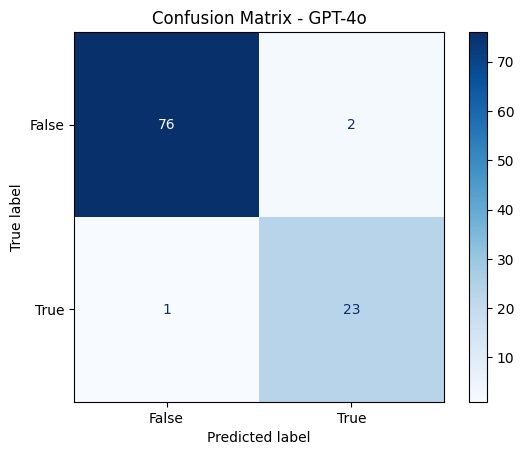

In [22]:
y_pred = df_eval["replication_gpt-4o"]
y_true = df_eval["replication_ground_truth"]

print(classification_report(y_true, y_pred, target_names=["False", "True"]))

cm = confusion_matrix(y_true, y_pred, labels=[False, True])
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["False", "True"])
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix - GPT-4o")
plt.show()

              precision    recall  f1-score   support

       False       0.97      0.85      0.90        78
        True       0.65      0.92      0.76        24

    accuracy                           0.86       102
   macro avg       0.81      0.88      0.83       102
weighted avg       0.89      0.86      0.87       102



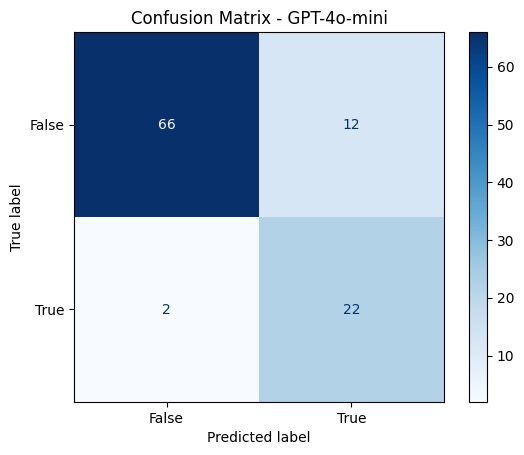

In [23]:
y_pred = df_eval["replication_gpt-4o-mini"]
y_true = df_eval["replication_ground_truth"]

print(classification_report(y_true, y_pred, target_names=["False", "True"]))

cm = confusion_matrix(y_true, y_pred, labels=[False, True])
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["False", "True"])
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix - GPT-4o-mini")
plt.show()

While 4o is clearly superior, 4o-mini still achieves high sensitivity (i.e. recall), meaning it correctly identifies all actual replications. However, 4o-mini has substantially worse specificity (i.e. precision), meaninig it identifies non-replications as replications.

* high sensitivity (i.e. lowest possible number in the bottom-left) = robust dataset/results
* low specificity (i.e. high number in top-right) = higher human labelling costs

## Cost calculations ($)

Assuming 7 completion tokens (as we won't be asking for a reason in production). Number of prompt tokens does not matter too much.

In [24]:
# batch API prices (except o1-mini, which does not have that)
# does not include Prompt Caching which only applies for prompts with 1024 tokens or more
df_price = pd.DataFrame([
    {"model": "gpt-4o", "price_per_prompt_token": 1.25/1_000_000, "price_per_completion_token": 5/1_000_000},
    {"model": "gpt-4o-mini", "price_per_prompt_token": 0.075/1_000_000, "price_per_completion_token": 0.3/1_000_000},
    {"model": "gpt-o1-mini", "price_per_prompt_token": 3.00/1_000_000, "price_per_completion_token": 12/1_000_000},
])

In [ ]:
mylist = []
with open("requests_log.jsonl", "rb") as file:
	for line in file:
		line = json.loads(line)
		mylist.append({
			'request_id': line['response']['_request_id'],
			'model': line['request']['model'],
			'prompt_tokens': line['response']['usage']['prompt_tokens'],
			# 'completion_tokens': line['response']['usage']['completion_tokens'],
		})

df_cost = pd.DataFrame(mylist)

# keep only evaluated prompts
evaluated_request_ids = df_eval['request_id_gpt-4o'].tolist() + df_eval['request_id_gpt-4o-mini'].tolist()
df_cost = df_cost[df_cost['request_id'].isin(evaluated_request_ids)]
# add price
df_cost = pd.merge(df_cost, df_price, how='left', on='model')
# calculate cost
# df_cost['cost'] = (df_cost['prompt_tokens'] * df_cost['price_per_prompt_token']) + (df_cost['completion_tokens'] * df_cost['price_per_completion_token'])
df_cost['cost'] = (df_cost['prompt_tokens'] * df_cost['price_per_prompt_token']) + (7 * df_cost['price_per_completion_token'])
df_cost.head()

,request_id,model,prompt_tokens,price_per_prompt_token,price_per_completion_token,cost
0,req_518b003213fc7064c9cb8dba22d7e787,gpt-4o,455,0.000001,0.000005,0.000604
1,req_e6258d440f5cb1677d8d98283a8abc3d,gpt-4o,386,0.000001,0.000005,0.000518
2,req_c85ff5ee0682ea29c5233d6c659cdf37,gpt-4o,494,0.000001,0.000005,0.000653
3,req_343df53693fb19113e9d5a0dc7ee9632,gpt-4o,498,0.000001,0.000005,0.000657
4,req_6b1201bd70a40522f93fbafa00a49460,gpt-4o,402,0.000001,0.000005,0.000538


In [26]:
df_cost_summary = df_cost.groupby("model").agg(
    requests=("cost", "count"),
    avg_prompt_tokens=("prompt_tokens", "mean"),
    # avg_completion_tokens=("completion_tokens", "mean"),
    avg_price_per_request=("cost", "mean"),
    total_price=("cost", "sum")
).reset_index(drop=False)
df_cost_summary['estimated_price_per_1000_requests'] = df_cost_summary['avg_price_per_request'] * 1_000
df_cost_summary

,model,requests,avg_prompt_tokens,avg_price_per_request,total_price,estimated_price_per_1000_requests
0,gpt-4o,102,468.568627,0.000621,0.063313,0.620711
1,gpt-4o-mini,102,468.568627,0.000037,0.003799,0.037243
